## 1. Data Preprocessing & Feature Engineering

In [1]:
import numpy as np
import pandas as pd

In [2]:
dataset = pd.read_csv("Churn_Modelling.csv")

dataset.head()

,RowNumber,CustomerId,Surname,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited
0,1,15634602,Hargrave,619,France,Female,42,2,0.00,1,1,1,101348.88,1
1,2,15647311,Hill,608,Spain,Female,41,1,83807.86,1,0,1,112542.58,0
2,3,15619304,Onio,502,France,Female,42,8,159660.80,3,1,0,113931.57,1
3,4,15701354,Boni,699,France,Female,39,1,0.00,2,0,0,93826.63,0
4,5,15737888,Mitchell,850,Spain,Female,43,2,125510.82,1,1,1,79084.10,0


In [3]:
X = dataset.iloc[:, 3:-1].values
y = dataset.iloc[:, -1].values

print(f"X: {X.shape}\n", X)
print(100*'=')
print(f"y: {y.shape}\n", y)

X: (10000, 10)
 [[619 'France' 'Female' ... 1 1 101348.88]
 [608 'Spain' 'Female' ... 0 1 112542.58]
 [502 'France' 'Female' ... 1 0 113931.57]
 ...
 [709 'France' 'Female' ... 0 1 42085.58]
 [772 'Germany' 'Male' ... 1 0 92888.52]
 [792 'France' 'Female' ... 1 0 38190.78]]
y: (10000,)
 [1 0 1 ... 1 1 0]


In [4]:
from sklearn.preprocessing import LabelEncoder
le = LabelEncoder()
X[:, 2] = le.fit_transform(X[:, 2])

print(f"X: {X.shape}\n", X)

X: (10000, 10)
 [[619 'France' 0 ... 1 1 101348.88]
 [608 'Spain' 0 ... 0 1 112542.58]
 [502 'France' 0 ... 1 0 113931.57]
 ...
 [709 'France' 0 ... 0 1 42085.58]
 [772 'Germany' 1 ... 1 0 92888.52]
 [792 'France' 0 ... 1 0 38190.78]]


In [5]:
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder
ct = ColumnTransformer(transformers=[('encoder', OneHotEncoder(), [1])], remainder='passthrough')
X = np.array(ct.fit_transform(X))

print(f"X: {X.shape}\n", X)

X: (10000, 12)
 [[1.0 0.0 0.0 ... 1 1 101348.88]
 [0.0 0.0 1.0 ... 0 1 112542.58]
 [1.0 0.0 0.0 ... 1 0 113931.57]
 ...
 [1.0 0.0 0.0 ... 0 1 42085.58]
 [0.0 1.0 0.0 ... 1 0 92888.52]
 [1.0 0.0 0.0 ... 1 0 38190.78]]


In [6]:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size = 0.2, random_state = 42)

In [7]:
from sklearn.preprocessing import StandardScaler
sc = StandardScaler()
X_train = sc.fit_transform(X_train)
X_test = sc.transform(X_test)

## 2. Building the Single-Layer Perceptron (SLP)

In [8]:
class SLP:
    def __init__(self, LR, X_train, y_train, X_test, y_test):
        self.w = np.random.randn(X_train.shape[1]) * 0.1
        self.b = np.random.randn() * 0.1
        self.LR = LR
        self.X_train = X_train
        self.y_train = y_train
        self.X_test = X_test
        self.y_test = y_test
        self.L_train = []
        self.L_test = []

    def activation(self, x):
        # sigmoid
        x = np.clip(x, -500, 500) 
        return 1 / (1 + np.exp(-x))
    
    def forward(self, X):
        hidden_1 = np.dot(X, self.w) + self.b
        activate_1 = self.activation(hidden_1)
        return activate_1

    def backward(self, X, y_true, y_pred):
        dL_dhidden1 = y_pred - y_true
        
        dhidden1_db = 1
        dhidden1_dw = X
        
        dL_db = dL_dhidden1 * dhidden1_db
        dL_dw = dL_dhidden1 * dhidden1_dw
        return dL_db, dL_dw
    
    def optimizer(self, dL_db, dL_dw):
        self.b -= dL_db * self.LR
        self.w -= dL_dw * self.LR

    def train(self, n_iter):
        for i in range(n_iter):
            # Stochastic Gradient Descent
            random_pos = np.random.randint(len(self.X_train))
            x_sample = self.X_train[random_pos]
            y_train_true = self.y_train[random_pos]

            y_train_pred = self.forward(x_sample)

            # BCE Loss
            pred_clipped = np.clip(y_train_pred, 1e-15, 1 - 1e-15)
            L = - (y_train_true * np.log(pred_clipped) + (1 - y_train_true) * np.log(1 - pred_clipped))
            self.L_train.append(L)

            dL_db, dL_dw = self.backward(x_sample, y_train_true, y_train_pred)
            self.optimizer(dL_db, dL_dw)

        self.evaluate_test()
        return "done."
    
    def evaluate_test(self):
        L_sum = 0
        for j in range(len(self.X_test)):
            y_true = self.y_test[j]
            y_pred = self.forward(self.X_test[j])
            pred_clipped = np.clip(y_pred, 1e-15, 1 - 1e-15)
            L_sum += - (y_true * np.log(pred_clipped) + (1 - y_true) * np.log(1 - pred_clipped))
        self.L_test.append(L_sum / len(self.X_test))

## 3. Model Hyperparameters & Training Execution

In [9]:
LR = 0.01
n_iter = 2000

In [10]:
slp = SLP(LR=LR, X_train=X_train, y_train=y_train, X_test=X_test, y_test=y_test)
slp.train(n_iter=n_iter)

'done.'

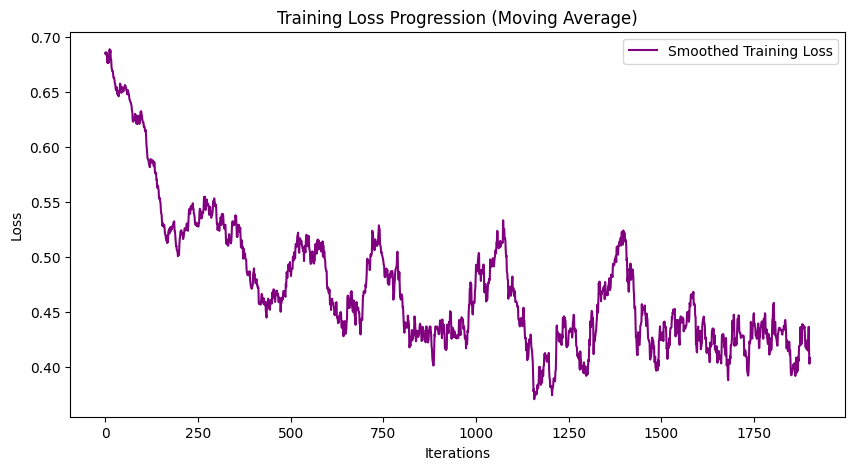

In [11]:
import matplotlib.pyplot as plt
window_size = 100
smoothed_loss = np.convolve(slp.L_train, np.ones(window_size)/window_size, mode='valid')

plt.figure(figsize=(10, 5))
plt.plot(smoothed_loss, color='purple', label='Smoothed Training Loss')
plt.title('Training Loss Progression (Moving Average)')
plt.xlabel('Iterations')
plt.ylabel('Loss')
plt.legend()
plt.show()

## 4. Model Evaluation & Performance Metrics

In [12]:
y_preds = np.round(slp.forward(X_test))

In [13]:
from sklearn.metrics import confusion_matrix, accuracy_score
print("--- Evaluation Results ---")
cm = confusion_matrix(y_test, y_preds)
print("Confusion Matrix:\n", cm)

acc = accuracy_score(y_test, y_preds)
print(f"Accuracy Score: {acc * 100:.2f}%")

--- Evaluation Results ---
Confusion Matrix:
 [[1571   36]
 [ 336   57]]
Accuracy Score: 81.40%


In [14]:
from collections import Counter
Counter(y_test)

Counter({np.int64(0): 1607, np.int64(1): 393})

In [15]:
# most-frequent classifier
1607 / (1607+393)

0.8035